In [25]:
import sys
sys.path.append("../src")

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from energy_load_forecast.ingestion import load_and_resample
from energy_load_forecast.preprocessing import clean_tail, add_calendar_features

In [26]:
path = Path("../data/raw/entsoe/load_RO_api_2025-07-01_2026-01-01.csv")
series = pd.read_csv(path, index_col="timestamp_utc")["load_mw"]
series.index = pd.to_datetime(series.index, utc=True)
series_clean = clean_tail(series)
df = add_calendar_features(series_clean.to_frame(name="load_mw"))

print("Shape:", df.shape)
print("Range:", df.index.min(), "to", df.index.max())


Shape: (4416, 5)
Range: 2025-07-01 00:00:00+00:00 to 2025-12-31 23:00:00+00:00


<Axes: xlabel='timestamp_utc'>

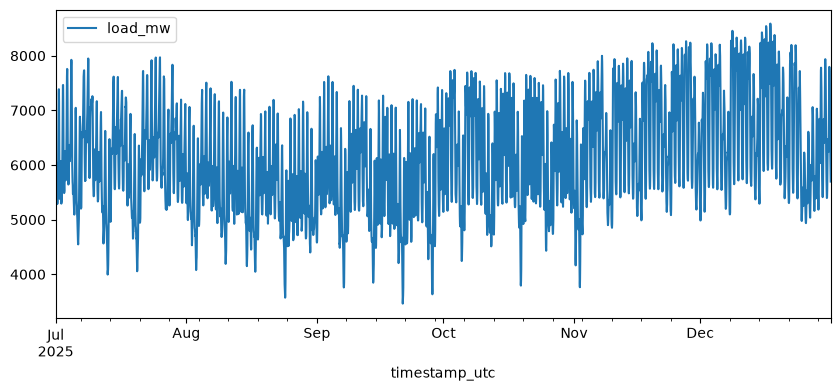

In [27]:
df.plot(y="load_mw", figsize=(10, 4))

Max: 20 7211.112853260869
Min: 3 5215.662486486487


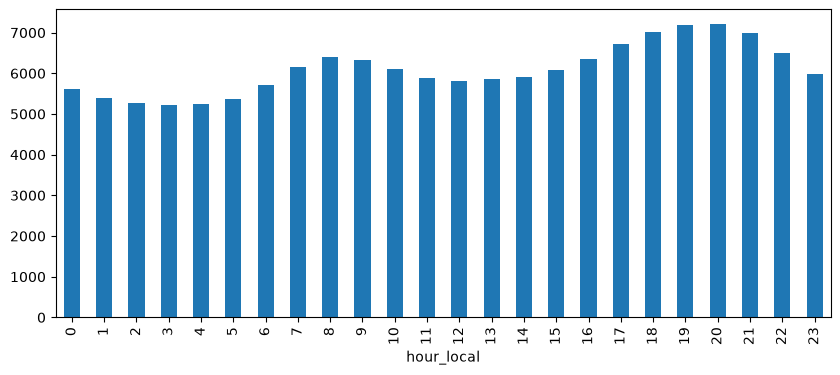

In [28]:
hourly_avg = df.groupby("hour_local")["load_mw"].mean()
hourly_avg.plot(kind="bar", figsize=(10, 4))

print("Max:", hourly_avg.idxmax(), hourly_avg.max())
print("Min:", hourly_avg.idxmin(), hourly_avg.min())

In [29]:
weekend_avg = df.groupby("is_weekend_local")["load_mw"].mean()
print(weekend_avg)

weekday_mean = weekend_avg.loc[False]
weekend_mean = weekend_avg.loc[True]

pct_drop = (weekday_mean - weekend_mean) / weekday_mean * 100
print("Percentage Drop: ", pct_drop)

is_weekend_local
False    6316.648761
True     5541.873699
Name: load_mw, dtype: float64
Percentage Drop:  12.26560302867067


<Axes: title={'center': 'Average load by day of week'}, xlabel='day_of_week_local'>

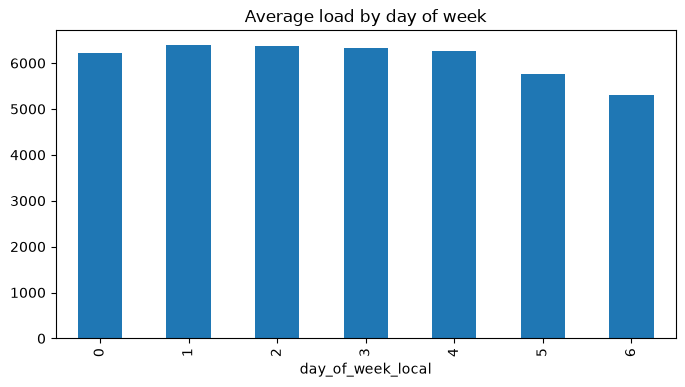

In [30]:
daily_avg = df.groupby("day_of_week_local")["load_mw"].mean()
daily_avg.plot(kind="bar", figsize=(8, 4), title="Average load by day of week")


<Axes: ylabel='Frequency'>

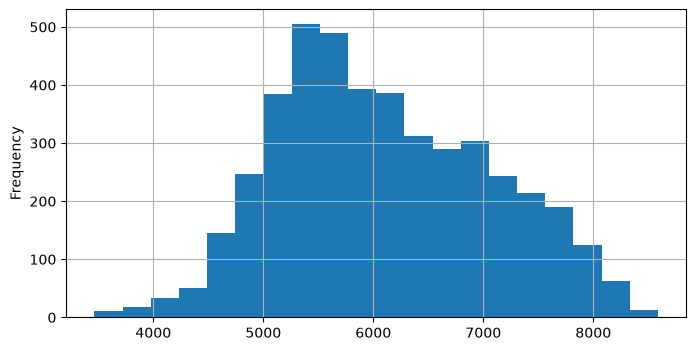

In [31]:
df["load_mw"].plot(kind="hist", bins=20, grid=True, figsize=(8, 4))

<Axes: >

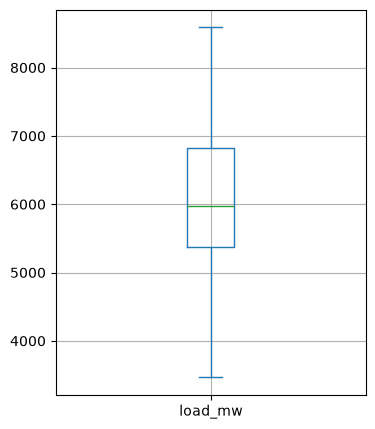

In [32]:
df["load_mw"].plot(kind="box", grid=True, figsize=(4, 5))

In [33]:
print(df["load_mw"].describe())
print("Smallest:\n", df["load_mw"].nsmallest(5))
print("Largest:\n", df["load_mw"].nlargest(5))

count    4416.000000
mean     6097.515144
std       963.662800
min      3464.000000
25%      5369.937500
50%      5974.750000
75%      6830.187500
max      8588.000000
Name: load_mw, dtype: float64
Smallest:
 timestamp_utc
2025-09-21 09:00:00+00:00    3464.00
2025-09-21 10:00:00+00:00    3526.25
2025-08-24 11:00:00+00:00    3572.75
2025-09-21 08:00:00+00:00    3577.25
2025-09-21 11:00:00+00:00    3613.50
Name: load_mw, dtype: float64
Largest:
 timestamp_utc
2025-12-17 15:00:00+00:00    8588.00
2025-12-16 15:00:00+00:00    8541.75
2025-12-17 16:00:00+00:00    8526.25
2025-12-16 16:00:00+00:00    8505.00
2025-12-08 15:00:00+00:00    8456.00
Name: load_mw, dtype: float64


Monthly averages:
 month_local
1     5809.875000
7     6119.621795
8     5553.329637
9     5632.082986
10    6084.985738
11    6496.459028
12    6697.346102
Name: load_mw, dtype: float64


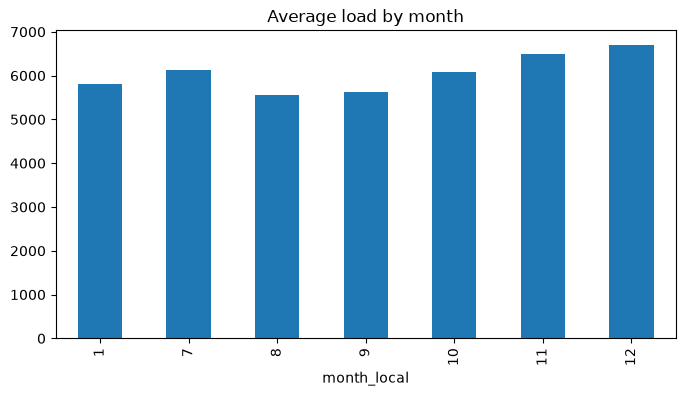

In [34]:
monthly_avg = df.groupby("month_local")["load_mw"].mean()
monthly_avg.plot(kind="bar", figsize=(8, 4), title="Average load by month")
print("Monthly averages:\n", monthly_avg)


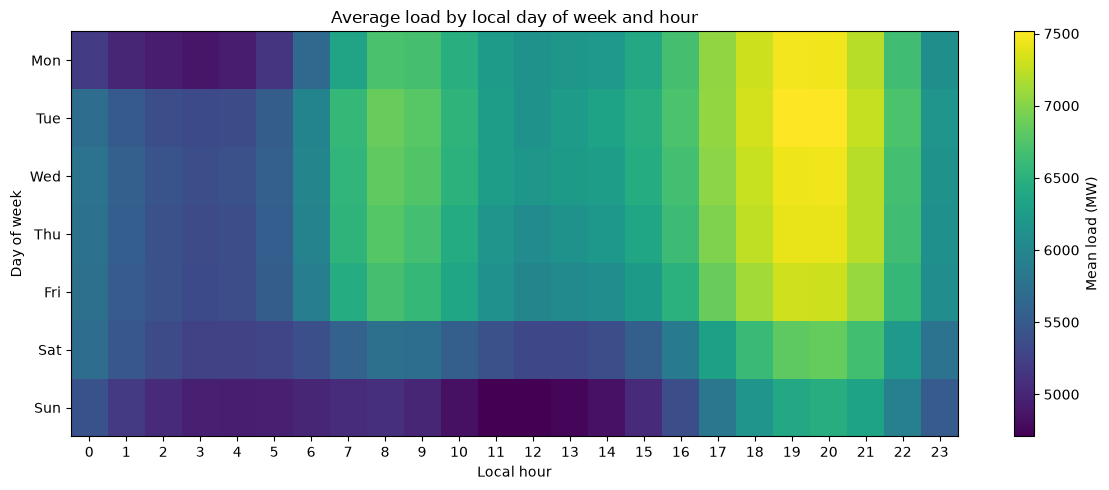

In [35]:
weekly_profile = df.pivot_table(
    index="day_of_week_local",
    columns="hour_local",
    values="load_mw",
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(weekly_profile, aspect="auto", interpolation="nearest")
ax.set_xlabel("Local hour")
ax.set_ylabel("Day of week")
ax.set_xticks(range(24))
ax.set_yticks(range(7))
ax.set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax.set_title("Average load by local day of week and hour")
fig.colorbar(im, ax=ax, label="Mean load (MW)")
fig.tight_layout()


In [36]:
daily_autocorr = df["load_mw"].autocorr(lag=24)
weekly_autocorr = df["load_mw"].autocorr(lag=168)

print(f"Autocorrelation at 24h lag: {daily_autocorr:.3f}")
print(f"Autocorrelation at 168h lag: {weekly_autocorr:.3f}")


Autocorrelation at 24h lag: 0.803
Autocorrelation at 168h lag: 0.855


### Interpretation

- A repeating hourly profile supports a daily seasonal component.
- Differences between weekdays and weekends support a weekly seasonal component.
- A monthly profile can show within-year changes, but it should not be presented as a fully estimated yearly seasonality because the dataset does not contain multiple complete annual cycles.
- The 24h autocorrelation is **0.803**, indicating strong daily persistence, while the 168h autocorrelation is **0.855**, indicating strong weekly persistence.